### Install Packages

In [1]:
# Install required packages
%pip install -q transformers datasets scikit-learn

### GPU Check

In [2]:
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")
if device == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Using device: cuda
GPU: Tesla T4
VRAM: 15.6 GB


### Mount Google Drive

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Upload Dataset

In [4]:
import shutil

drive_csv_path = "/content/drive/MyDrive/Final Year Research Project (FYP)/Implementations/Feedback/nlp_tryout/Dataset/nav_dataset.csv"
shutil.copy(drive_csv_path, "nav_dataset.csv")
print("Dataset ready!")

Dataset ready!


### Load and Split Dataset

In [5]:
import pandas as pd
from datasets import Dataset
from sklearn.model_selection import train_test_split

# Load your CSV
df = pd.read_csv("nav_dataset.csv")

# Remove exact duplicates based on both input and target
before_rows = len(df)
df = df.drop_duplicates(subset=["input", "target"]).reset_index(drop=True)
after_rows = len(df)
removed_rows = before_rows - after_rows

print("Data cleanup summary")
print(f"Rows before cleanup: {before_rows}")
print(f"Duplicate rows removed: {removed_rows}")
print(f"Rows remaining: {after_rows}")

# Split: 80% train, 10% validation, 10% test
train_df, temp_df = train_test_split(df, test_size=0.2, random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)

train_dataset = Dataset.from_pandas(train_df.reset_index(drop=True))
val_dataset = Dataset.from_pandas(val_df.reset_index(drop=True))
test_dataset = Dataset.from_pandas(test_df.reset_index(drop=True))

print(f"Training examples: {len(train_dataset)}")
print(f"Validation examples: {len(val_dataset)}")
print(f"Test examples: {len(test_dataset)}")

Data cleanup summary
Rows before cleanup: 2350
Duplicate rows removed: 523
Rows remaining: 1827
Training examples: 1461
Validation examples: 183
Test examples: 183


### Tokenize Data

In [6]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("t5-small")

def preprocess(examples):
    model_inputs = tokenizer(
        ["navigate: " + x for x in examples["input"]],
        max_length=128,
        truncation=True,
    )
    labels = tokenizer(
        text_target=examples["target"],
        max_length=64,
        truncation=True,
    )
    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

tokenized_train = train_dataset.map(preprocess, batched=True, remove_columns=train_dataset.column_names)
tokenized_val = val_dataset.map(preprocess, batched=True, remove_columns=val_dataset.column_names)
tokenized_test = test_dataset.map(preprocess, batched=True, remove_columns=test_dataset.column_names)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/1461 [00:00<?, ? examples/s]

Map:   0%|          | 0/183 [00:00<?, ? examples/s]

Map:   0%|          | 0/183 [00:00<?, ? examples/s]

### Model Loading and Configuration

In [7]:
from transformers import T5ForConditionalGeneration, TrainingArguments, Trainer, DataCollatorForSeq2Seq

model = T5ForConditionalGeneration.from_pretrained("t5-small")
data_collator = DataCollatorForSeq2Seq(tokenizer=tokenizer, model=model)

training_args = TrainingArguments(
    output_dir="./nav_t5_model_v1",
    num_train_epochs=15,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    warmup_steps=100,
    weight_decay=0.01,
    logging_dir="./logs",
    logging_steps=10,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    fp16=True,
    remove_unused_columns=False,
    report_to="none",
    lr_scheduler_type="cosine",
    learning_rate=3e-4,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    processing_class=tokenizer,
    data_collator=data_collator,
)

model.safetensors:   0%|          | 0.00/242M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


### Train the model

In [8]:
train_result = trainer.train()
print(train_result.metrics)

Epoch,Training Loss,Validation Loss
1,2.003387,1.178327
2,0.860672,0.654249
3,0.663912,0.532719
4,0.609061,0.506194
5,0.539780,0.491239
6,0.482195,0.464888
7,0.512145,0.458604
8,0.457962,0.448691
9,0.483882,0.442060
10,0.439363,0.438617


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['encoder.embed_tokens.weight', 'decoder.embed_tokens.weight', 'lm_head.weight'].


{'train_runtime': 181.9965, 'train_samples_per_second': 120.414, 'train_steps_per_second': 3.791, 'total_flos': 110129104158720.0, 'train_loss': 0.6945000686507294, 'epoch': 15.0}


### Training Curves (Overfit / Underfit Check)
Plot training and validation loss from trainer logs to inspect model fit quality.

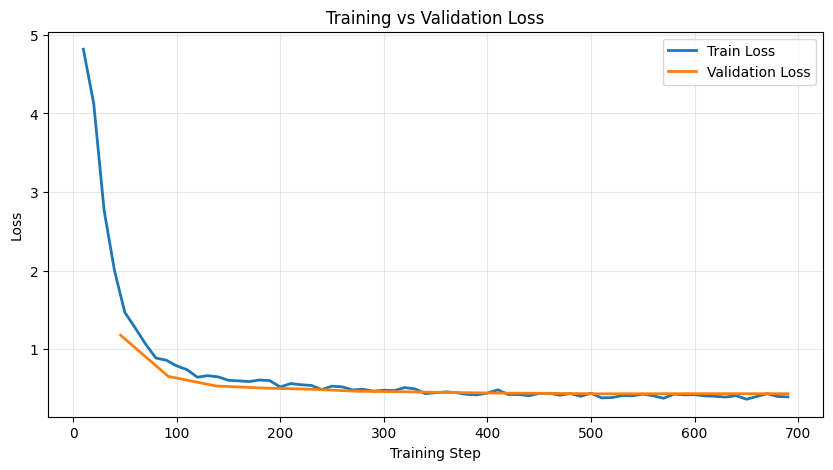

Latest train loss: 0.3938
Latest val loss:   0.4341
Generalization gap (val - train): 0.0403
Fit looks reasonable so far; confirm with held-out test metrics.


In [9]:
import pandas as pd
import matplotlib.pyplot as plt

log_df = pd.DataFrame(trainer.state.log_history)
train_loss_df = log_df.dropna(subset=["loss"])[["step", "epoch", "loss"]].copy()
eval_loss_df = log_df.dropna(subset=["eval_loss"])[["step", "epoch", "eval_loss"]].copy()

if train_loss_df.empty or eval_loss_df.empty:
    print("Not enough log data to plot train/eval losses.")
else:
    plt.figure(figsize=(10, 5))
    plt.plot(train_loss_df["step"], train_loss_df["loss"], label="Train Loss", linewidth=2)
    plt.plot(eval_loss_df["step"], eval_loss_df["eval_loss"], label="Validation Loss", linewidth=2)
    plt.xlabel("Training Step")
    plt.ylabel("Loss")
    plt.title("Training vs Validation Loss")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    latest_train_loss = float(train_loss_df.iloc[-1]["loss"])
    latest_val_loss = float(eval_loss_df.iloc[-1]["eval_loss"])
    loss_gap = latest_val_loss - latest_train_loss

    print(f"Latest train loss: {latest_train_loss:.4f}")
    print(f"Latest val loss:   {latest_val_loss:.4f}")
    print(f"Generalization gap (val - train): {loss_gap:.4f}")

    if loss_gap > 0.5:
        print("Potential overfitting signal: validation loss is much higher than training loss.")
    elif latest_train_loss > 1.5 and latest_val_loss > 1.5:
        print("Potential underfitting signal: both losses are still relatively high.")
    else:
        print("Fit looks reasonable so far; confirm with held-out test metrics.")

### Save Model

In [10]:
save_path = "/content/drive/MyDrive/Final Year Research Project (FYP)/Implementations/Feedback/nlp_tryout/models/nav_t5_final_v1"
trainer.save_model(save_path)
tokenizer.save_pretrained(save_path)
print(f"Model saved to {save_path}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to /content/drive/MyDrive/Final Year Research Project (FYP)/Implementations/Feedback/nlp_tryout/models/nav_t5_final_v1


### Test Model

In [11]:
### Test the Fine-Tuned Model
from transformers import T5ForConditionalGeneration, AutoTokenizer

model_path = "/content/drive/MyDrive/Final Year Research Project (FYP)/Implementations/Feedback/nlp_tryout/models/nav_t5_final_v1"
tokenizer = AutoTokenizer.from_pretrained(model_path)
model = T5ForConditionalGeneration.from_pretrained(model_path)
model = model.to(device)
model.eval()

def generate_instruction(nav_json: dict) -> str:
    parts = [f"{k}: {v}" for k, v in nav_json.items()]
    input_text = "navigate: " + " ".join(parts)
    inputs = tokenizer(input_text, return_tensors="pt", max_length=128, truncation=True)
    inputs = {k: v.to(device) for k, v in inputs.items()}
    outputs = model.generate(
        **inputs,
        max_length=64,
        min_new_tokens=4,
        num_beams=4,
        early_stopping=True
    )
    result = tokenizer.decode(outputs[0], skip_special_tokens=True).strip()
    return result if result else "[empty output - retrain with corrected label masking]"

test_cases = [
    {"action": "turn", "direction": "left", "distance": "10m", "landmark": "reception desk"},
    {"action": "continue", "distance": "20m"},
    {"action": "arrive", "landmark": "platform 3"},
    {"action": "stop", "reason": "hazard", "description": "wet floor"},
    {"action": "turn", "direction": "right", "distance": "5m", "landmark": "main entrance"},
]

print("=" * 60)
for tc in test_cases:
    print(f"Input:  {tc}")
    print(f"Output: {generate_instruction(tc)}")
    print("-" * 60)

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

Input:  {'action': 'turn', 'direction': 'left', 'distance': '10m', 'landmark': 'reception desk'}
Output: Turn left and walk 10m to the reception desk.
------------------------------------------------------------
Input:  {'action': 'continue', 'distance': '20m'}
Output: Walk straight for 20m.
------------------------------------------------------------
Input:  {'action': 'arrive', 'landmark': 'platform 3'}
Output: Arrived at the platform 3.
------------------------------------------------------------
Input:  {'action': 'stop', 'reason': 'hazard', 'description': 'wet floor'}
Output: Stop here. You have reached the wet floor.
------------------------------------------------------------
Input:  {'action': 'turn', 'direction': 'right', 'distance': '5m', 'landmark': 'main entrance'}
Output: Turn right and walk 5m to the main entrance.
------------------------------------------------------------


### Comparison Against Baseline

In [12]:
def template_instruction(nav_json: dict) -> str:
    action = nav_json.get("action")
    if action == "turn":
        return f"In {nav_json['distance']}, turn {nav_json['direction']} towards the {nav_json.get('landmark', 'next point')}."
    elif action == "continue":
        return f"Continue straight for {nav_json['distance']}."
    elif action == "arrive":
        return f"You have arrived at the {nav_json['landmark']}."
    elif action == "stop":
        return f"Stop. {nav_json.get('description', 'Obstacle')} ahead."
    return "Proceed as directed."

print("\nCOMPARISON: Fine-tuned model vs Template")
print("=" * 60)
for tc in test_cases:
    print(f"Input:    {tc}")
    print(f"Template: {template_instruction(tc)}")
    print(f"T5 Model: {generate_instruction(tc)}")
    print("-" * 60)

print("\nSUMMARY")
print("=" * 60)
matches = 0
for tc in test_cases:
    t = template_instruction(tc)
    m = generate_instruction(tc)
    match = "SAME" if t.strip().lower() == m.strip().lower() else "DIFF"
    if match == "SAME":
        matches += 1
    print(f"[{match}] {tc['action']}")
print(f"\nExact matches: {matches}/{len(test_cases)}")


COMPARISON: Fine-tuned model vs Template
Input:    {'action': 'turn', 'direction': 'left', 'distance': '10m', 'landmark': 'reception desk'}
Template: In 10m, turn left towards the reception desk.
T5 Model: Turn left and walk 10m to the reception desk.
------------------------------------------------------------
Input:    {'action': 'continue', 'distance': '20m'}
Template: Continue straight for 20m.
T5 Model: Walk straight for 20m.
------------------------------------------------------------
Input:    {'action': 'arrive', 'landmark': 'platform 3'}
Template: You have arrived at the platform 3.
T5 Model: Arrived at the platform 3.
------------------------------------------------------------
Input:    {'action': 'stop', 'reason': 'hazard', 'description': 'wet floor'}
Template: Stop. wet floor ahead.
T5 Model: Stop here. You have reached the wet floor.
------------------------------------------------------------
Input:    {'action': 'turn', 'direction': 'right', 'distance': '5m', 'landmark